In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
class LSTMScratch(torch.nn.Module):
  def __init__(self, num_inputs, num_hiddens, sigma=0.01):
    super().__init__()
    self.num_inputs, self.num_hiddens, self.sigma = num_inputs, num_hiddens, sigma
    init_weight = lambda *shape: torch.nn.Parameter(torch.randn(*shape) * sigma)
    triple = lambda: (init_weight(num_inputs, num_hiddens), init_weight(num_hiddens, num_hiddens), torch.nn.Parameter(torch.zeros(num_hiddens)))
    self.W_xi, self.W_hi, self.b_i = triple()
    self.W_xf, self.W_hf, self.b_f = triple()
    self.W_xo, self.W_ho, self.b_o = triple()
    self.W_xc, self.W_hc, self.b_c = triple()
  def forward(self, inputs, H_C=None):
    if H_C is None:
      H = torch.zeros((inputs.shape[1], self.num_hiddens), device=inputs.device)
      C = torch.zeros((inputs.shape[1], self.num_hiddens), device=inputs.device)
    else:
      H, C = H_C
    outputs = []
    for X in inputs:
      I = torch.sigmoid(X @ self.W_xi + H @ self.W_hi + self.b_i)
      F = torch.sigmoid(X @ self.W_xf + H @ self.W_hf + self.b_f)
      O = torch.sigmoid(X @ self.W_xo + H @ self.W_ho + self.b_o)
      C_tilde = torch.tanh(X @ self.W_xc + H @ self.W_hc + self.b_c)
      C = F * C + I * C_tilde
      H = O * torch.tanh(C)
      outputs.append(H)
    return torch.stack(outputs), (H, C)

In [3]:
import requests
from collections import Counter

In [4]:
class Vocab:
  def __init__(self, tokens, reserved_words=[], min_freq=0):
    hist = Counter(tokens)
    self.token_freq = sorted(hist.items(), key=lambda x: x[1], reverse=True)
    self.tokens = list(set(reserved_words + ['<unk>'] + [token for token, freq in self.token_freq if freq >= min_freq]))
    self.reverse_map = {token: idx for idx, token in enumerate(self.tokens)}
  def __len__(self):
    return len(self.tokens)
  def __getitem__(self, token):
    if(isinstance(token, (list, tuple))):
      return [self.__getitem__(i) for i in token]
    else:
      return self.reverse_map.get(token, self.unk)
  def get_tokens(self, idxs):
    if(isinstance(idxs, (list, tuple))):
      return [self.tokens[i] for i in idxs]
    else:
      return self.tokens[idxs]
  @property
  def unk(self):
    return self.reverse_map['<unk>']

In [5]:
time_machine_url = 'https://www.gutenberg.org/cache/epub/35/pg35.txt'

In [31]:
corpus = requests.get(time_machine_url).text
words =  corpus.split()
vocab = Vocab(words)
time_machine_list = [vocab[word] for word in words]

In [32]:
batch_size = 1024
num_steps = 32

In [33]:
input_tensor, output_tensor = torch.stack([torch.tensor(time_machine_list[i:len(time_machine_list) - num_steps + i]) for i in range(num_steps)], 1), torch.stack([torch.tensor(time_machine_list[i + 1:len(time_machine_list) - num_steps + i + 1]) for i in range(num_steps)], 1)

In [34]:
dataset = torch.utils.data.dataset.TensorDataset(input_tensor, output_tensor)

In [35]:
train_size = int(0.8 * len(input_tensor))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_dataloader = torch.utils.data.dataloader.DataLoader(train_dataset, batch_size=batch_size)
val_dataloader = torch.utils.data.dataloader.DataLoader(val_dataset, batch_size=batch_size)

In [36]:
num_hiddens = 32

In [12]:
lstm = LSTMScratch(num_inputs=len(vocab), num_hiddens=num_hiddens)

In [15]:
class RNNLM(torch.nn.Module):
  def __init__(self, vocab_size:int, rnn, lr=0.01):
    super().__init__()
    self.vocab_size = vocab_size
    self.rnn = rnn
    self.linear = torch.nn.LazyLinear(self.vocab_size)
    self.loss = torch.nn.CrossEntropyLoss()

  def training_step(self, batch):
    preds = self(*batch[:-1])
    targets = batch[-1]
    l = self.loss(preds.permute(0, 2, 1), batch[-1])
    return l

  def validation_step(self, batch):
    preds = self(*batch[:-1])
    targets = batch[-1]
    l = self.loss(preds.permute(0, 2, 1), batch[-1])
    return l

  def one_hot(self, x):
    return torch.nn.functional.one_hot(x.T, self.vocab_size).type(torch.float32)

  def output_layer(self, rnn_outputs):
    return self.linear(rnn_outputs).swapaxes(0, 1)

  def forward(self, inputs, state=None):
    rnn_outputs, state = self.rnn(self.one_hot(inputs.to(self.linear.weight.device)), state)
    return self.output_layer(rnn_outputs)
  def predict(self, prefix, num_preds, vocab, device=None):
    state, outputs = None, [vocab[prefix[0]]] # FIX: Use vocab for prefix[0]
    for i in range(len(prefix) + num_preds - 1):
        X = torch.tensor([[outputs[-1]]], device=device)
        embs = self.one_hot(X)
        rnn_outputs, state = self.rnn(embs, state)
        if i < len(prefix) - 1:  # Warm-up period
            outputs.append(vocab[prefix[i + 1]]) # FIX: Use vocab for prefix[i+1]
        else:  # Predict num_preds steps
            Y = self.output_layer(rnn_outputs)
            outputs.append(int(Y.argmax(2).reshape(1)))
    return ''.join([vocab.get_tokens(i) for i in outputs])

In [16]:
lr = 4

In [17]:
model = RNNLM(len(vocab), lstm, lr=lr)

In [18]:
max_epochs = 50
max_grad = 1

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [20]:
model = model.to(device)

In [21]:
train_loss = []
val_loss = []
optim = torch.optim.SGD(model.parameters(), lr=lr)
for epoch in range(1, max_epochs + 1):
  total_loss = 0
  num_batches = 0
  for X, y in train_dataloader:
    # Move batch data to the device
    X, y = X.to(device), y.to(device)
    model.train()

    optim.zero_grad()
    # `X` will now be `(inputs_batch, targets_batch)` from the dataloader.
    # The `training_step` expects `batch` to be `(inputs, targets)` for `self(*batch[:-1]), batch[-1])`
    # So, `model.training_step((X, y))` or `model.training_step(X, y)` is needed if it takes separate args.
    # Given `l = self.loss(self(*batch[:-1]), batch[-1])`, `batch` should be `(X, y)`.
    # So, `model.training_step((X, y))` will correctly unpack as `*batch[:-1]` -> `X` and `batch[-1]` -> `y`.
    l = model.training_step((X, y))
    l.backward()
    parameter_list = [p for p in model.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum(p.grad ** 2) for p in parameter_list))
    if norm > max_grad:
      for p in parameter_list:
        p.grad[:] = p.grad[:] / norm * max_grad # Correct gradient clipping: scale by max_grad/norm
    optim.step()
    total_loss += l.item()
    num_batches += 1
  avg_loss = total_loss / num_batches if num_batches > 0 else 0
  train_loss.append(torch.exp(torch.tensor(avg_loss)))
  model.eval()
  num_batches = 0
  total_loss = 0
  for X, y in val_dataloader:
    X, y = X.to(device), y.to(device)
    l = model.validation_step((X, y))
    total_loss += l.item()
    num_batches += 1
  avg_loss = total_loss / num_batches if num_batches > 0 else 0
  val_loss.append(torch.exp(torch.tensor(avg_loss)))

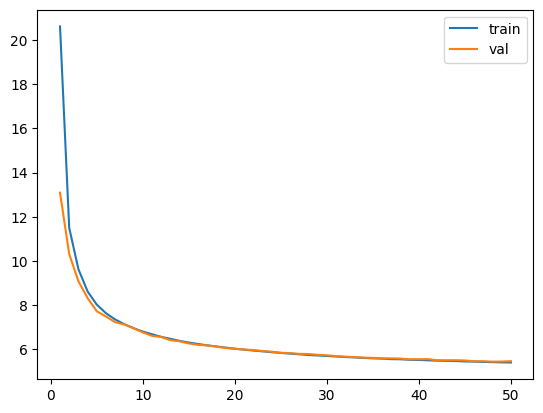

In [22]:
plt.plot(list(range(1, max_epochs + 1)), train_loss, label='train')
plt.plot(list(range(1, max_epochs + 1)), val_loss, label='val')
plt.legend()
plt.show()

In [23]:
model.predict('it has', 20, vocab, device)

'it has and the sun and the'

In [24]:
class LSTM(torch.nn.Module):
  def __init__(self, num_inputs, num_hiddens):
    super().__init__()
    self.num_inputs, self.num_hiddens, = num_inputs, num_hiddens
    self.rnn = torch.nn.LSTM(num_inputs, num_hiddens)
  def forward(self, inputs, H_C=None):
    return self.rnn(inputs, H_C)

In [37]:
lstm = LSTM(num_inputs=len(vocab), num_hiddens=num_hiddens)

In [38]:
model = RNNLM(len(vocab), lstm, lr=lr)

In [39]:
model = model.to(device)

In [40]:
train_loss = []
val_loss = []
optim = torch.optim.SGD(model.parameters(), lr=lr)
for epoch in range(1, max_epochs + 1):
  total_loss = 0
  num_batches = 0
  for X, y in train_dataloader:
    # Move batch data to the device
    X, y = X.to(device), y.to(device)
    model.train()

    optim.zero_grad()
    # `X` will now be `(inputs_batch, targets_batch)` from the dataloader.
    # The `training_step` expects `batch` to be `(inputs, targets)` for `self(*batch[:-1]), batch[-1])`
    # So, `model.training_step((X, y))` or `model.training_step(X, y)` is needed if it takes separate args.
    # Given `l = self.loss(self(*batch[:-1]), batch[-1])`, `batch` should be `(X, y)`.
    # So, `model.training_step((X, y))` will correctly unpack as `*batch[:-1]` -> `X` and `batch[-1]` -> `y`.
    l = model.training_step((X, y))
    l.backward()
    parameter_list = [p for p in model.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum(p.grad ** 2) for p in parameter_list))
    if norm > max_grad:
      for p in parameter_list:
        p.grad[:] = p.grad[:] / norm * max_grad # Correct gradient clipping: scale by max_grad/norm
    optim.step()
    total_loss += l.item()
    num_batches += 1
  avg_loss = total_loss / num_batches if num_batches > 0 else 0
  train_loss.append(torch.exp(torch.tensor(avg_loss)))
  model.eval()
  num_batches = 0
  total_loss = 0
  for X, y in val_dataloader:
    X, y = X.to(device), y.to(device)
    l = model.validation_step((X, y))
    total_loss += l.item()
    num_batches += 1
  avg_loss = total_loss / num_batches if num_batches > 0 else 0
  val_loss.append(torch.exp(torch.tensor(avg_loss)))

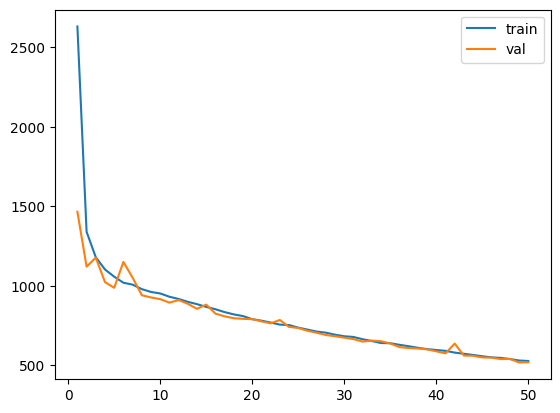

In [41]:
plt.plot(list(range(1, max_epochs + 1)), train_loss, label='train')
plt.plot(list(range(1, max_epochs + 1)), val_loss, label='val')
plt.legend()
plt.show()

In [42]:
model.predict('it has'.split(), 20, vocab, device)

'ithastothelittleoftheTimeTravellerwasalittleoftheTimeTravellerwasalittleoftheTime'